## Modelo Baseline - Dataset Boston Housing

### By:
Rafael Garcia

### Date:
2026-08-20

### Description:

Este notebook corresponde a la **Tarea 5: Modelo Baseline** del Proyecto 1 (Dataset Estático) del curso de MLOps.

El objetivo es crear un modelo base de referencia para comparar al entrenar modelos de machine learning. Se utiliza un `DummyRegressor` de scikit-learn y el modelo heurístico explorado en el EDA (Tarea 3). Se incluye:

- Pipeline de procesamiento + modelo baseline
- Evaluación con múltiples métricas
- Validación cruzada con media y desviación estándar
- Análisis de Learning Curve
- Gráficas de escalabilidad
- Análisis e interpretación de resultados
- Recomendaciones para el modelado

## 📚 Import libraries

In [42]:
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import cross_validate, learning_curve
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)

## 💾 Load data

In [43]:
# Cargar datos limpios (pre-split)
df = pd.read_parquet("../../data/02_intermediate/boston_housing_clean.parquet")

TARGET = "medv"
ID_COL = "ID"

# Eliminar ID y filas sin target (mismo proceso que Tarea 4)
df = df.drop(columns=[ID_COL])
df = df.dropna(subset=[TARGET])

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Dataset: {X.shape[0]} filas, {X.shape[1]} features")
print(f"Target (medv): media={y.mean():.2f}, mediana={y.median():.2f}, std={y.std():.2f}")

Dataset: 432 filas, 13 features
Target (medv): media=21.99, mediana=20.60, std=9.22


In [44]:
# División Train / Test (misma semilla que Tarea 4)
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Convertir tipos para compatibilidad con el pipeline
X_train["chas"] = X_train["chas"].astype(str)
X_test["chas"] = X_test["chas"].astype(str)
X_train["rad"] = X_train["rad"].astype(float)
X_test["rad"] = X_test["rad"].astype(float)

# Hacer lo mismo en X completo para cross validation
X_cv = X.copy()
X_cv["chas"] = X_cv["chas"].astype(str)
X_cv["rad"] = X_cv["rad"].astype(float)

print(f"Train: {X_train.shape[0]} filas")
print(f"Test:  {X_test.shape[0]} filas")

Train: 345 filas
Test:  87 filas


## ⚙️ Cargar pipeline de preprocesamiento

In [45]:
# Cargar preprocessor de la Tarea 4
preprocessor = joblib.load("../../models/preprocessor.joblib")
print("Preprocessor cargado correctamente")
print(preprocessor)

Preprocessor cargado correctamente
ColumnTransformer(transformers=[('log',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('log_transform',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>,
                                                                      validate=True)),
                                                 ('scaler', StandardScaler())]),
                                 ['crim', 'zn', 'dis', 'lstat']),
                                ('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                 

## 🏗️ Definición de modelos baseline

Se crean dos modelos baseline:

1. **DummyRegressor (media)**: predice siempre la media del target. Es el piso absoluto de rendimiento.
2. **DummyRegressor (mediana)**: predice siempre la mediana del target. Más robusto a outliers.

In [46]:
# Pipeline completo: preprocessor + modelo baseline
baseline_mean = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="mean")),
    ]
)

baseline_median = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="median")),
    ]
)

print("Pipeline baseline (media):")
print(baseline_mean)
print("\nPipeline baseline (mediana):")
print(baseline_median)

Pipeline baseline (media):
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('log',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log_transform',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>,
                                                                                       validate=True)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['crim', 'zn', 'dis',
                                                  

## 📏 Evaluación con múltiples métricas

In [47]:
def evaluate_model(model, train_data, test_data, model_name):
    """Entrena y evalúa un modelo con múltiples métricas."""
    X_tr, y_tr = train_data
    X_te, y_te = test_data

    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_te)
    pred_time = time.time() - start

    results = {
        "Modelo": model_name,
        "RMSE": np.sqrt(mean_squared_error(y_te, y_pred)),
        "MAE": mean_absolute_error(y_te, y_pred),
        "MAPE": mean_absolute_percentage_error(y_te, y_pred),
        "R2": r2_score(y_te, y_pred),
        "Tiempo_train (s)": train_time,
        "Tiempo_pred (s)": pred_time,
    }
    return results, y_pred

In [48]:
# Evaluar ambos baselines
results_mean, y_pred_mean = evaluate_model(
    baseline_mean, (X_train, y_train), (X_test, y_test), "Baseline (media)"
)
results_median, y_pred_median = evaluate_model(
    baseline_median, (X_train, y_train), (X_test, y_test), "Baseline (mediana)"
)

results_df = pd.DataFrame([results_mean, results_median]).set_index("Modelo")
print("=== Evaluación en Test ===")
results_df.round(4)

=== Evaluación en Test ===


,RMSE,MAE,MAPE,R2,Tiempo_train (s),Tiempo_pred (s)
Modelo,,,,,,
Baseline (media),9.9021,6.893,0.3557,-0.0053,0.0267,0.0120
Baseline (mediana),10.0689,6.792,0.3308,-0.0395,0.0172,0.0066


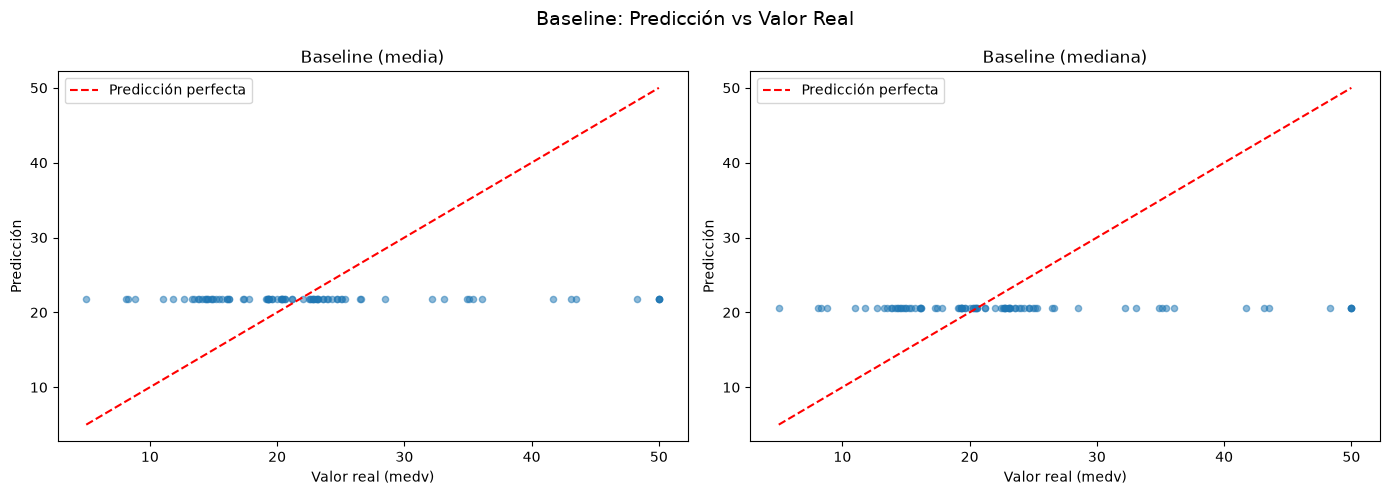

In [49]:
# Visualización: predicción vs real
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, name in [
    (axes[0], y_pred_mean, "Baseline (media)"),
    (axes[1], y_pred_median, "Baseline (mediana)"),
]:
    ax.scatter(y_test, y_pred, alpha=0.5, s=20)
    ax.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        "r--",
        label="Predicción perfecta",
    )
    ax.set_xlabel("Valor real (medv)")
    ax.set_ylabel("Predicción")
    ax.set_title(name)
    ax.legend()

plt.suptitle("Baseline: Predicción vs Valor Real", fontsize=14)
plt.tight_layout()
plt.show()

## 🔄 Validación cruzada (Cross Validation)

In [50]:
N_FOLDS = 10

SCORING = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

# Cross validation para baseline media
cv_mean = cross_validate(
    baseline_mean,
    X_cv,
    y,
    cv=N_FOLDS,
    scoring=SCORING,
    return_train_score=True,
)

# Cross validation para baseline mediana
cv_median = cross_validate(
    baseline_median,
    X_cv,
    y,
    cv=N_FOLDS,
    scoring=SCORING,
    return_train_score=True,
)

In [51]:
# Resumen de cross validation
print(f"=== Validación Cruzada ({N_FOLDS} folds) ===")
print()

for name, cv_results in [("Baseline (media)", cv_mean), ("Baseline (mediana)", cv_median)]:
    print(f"--- {name} ---")
    for metric_name, _scorer_name in SCORING.items():
        test_key = f"test_{metric_name}"
        scores = cv_results[test_key]
        # RMSE y MAE vienen negados en sklearn
        if metric_name in ("RMSE", "MAE"):
            scores = -scores
        print(f"  {metric_name}: {scores.mean():.4f} ± {scores.std():.4f}")
    print()

=== Validación Cruzada (10 folds) ===

--- Baseline (media) ---
  RMSE: 8.9603 ± 3.0457
  MAE: 6.9071 ± 2.3279
  R2: -0.5962 ± 1.1300

--- Baseline (mediana) ---
  RMSE: 8.9464 ± 3.2106
  MAE: 6.7846 ± 2.4929
  R2: -0.5292 ± 0.8765



## 📊 Selección de la métrica más importante

Se selecciona **RMSE** como la métrica principal por las siguientes razones:

1. Está en las mismas unidades que la variable objetivo (miles de USD), lo que facilita la interpretación.
2. Penaliza los errores grandes más que MAE, lo cual es importante en predicción de precios de viviendas donde un error grande tiene consecuencias financieras significativas.
3. Es consistente con la decisión tomada en la Tarea 1 (entendimiento del problema).

El **R²** se mantiene como métrica complementaria para comunicar el porcentaje de varianza explicada.

## 📈 Análisis de Learning Curve

In [52]:
def plot_learning_curve(estimator, X, y, config):
    """Genera la curva de aprendizaje para un estimador."""
    ax = config["ax"]
    cv = config.get("cv", N_FOLDS)
    title = config["title"]
    train_sizes = np.linspace(0.1, 1.0, 10)

    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        train_sizes=train_sizes,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )

    train_scores = -train_scores
    test_scores = -test_scores

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)

    ax.fill_between(
        train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue"
    )
    ax.fill_between(
        train_sizes_abs, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange"
    )
    ax.plot(train_sizes_abs, train_mean, "o-", color="blue", label="Train RMSE")
    ax.plot(train_sizes_abs, test_mean, "o-", color="orange", label="Validation RMSE")
    ax.set_xlabel("Tamaño del conjunto de entrenamiento")
    ax.set_ylabel("RMSE")
    ax.set_title(title)
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

    return train_sizes_abs, train_scores, test_scores

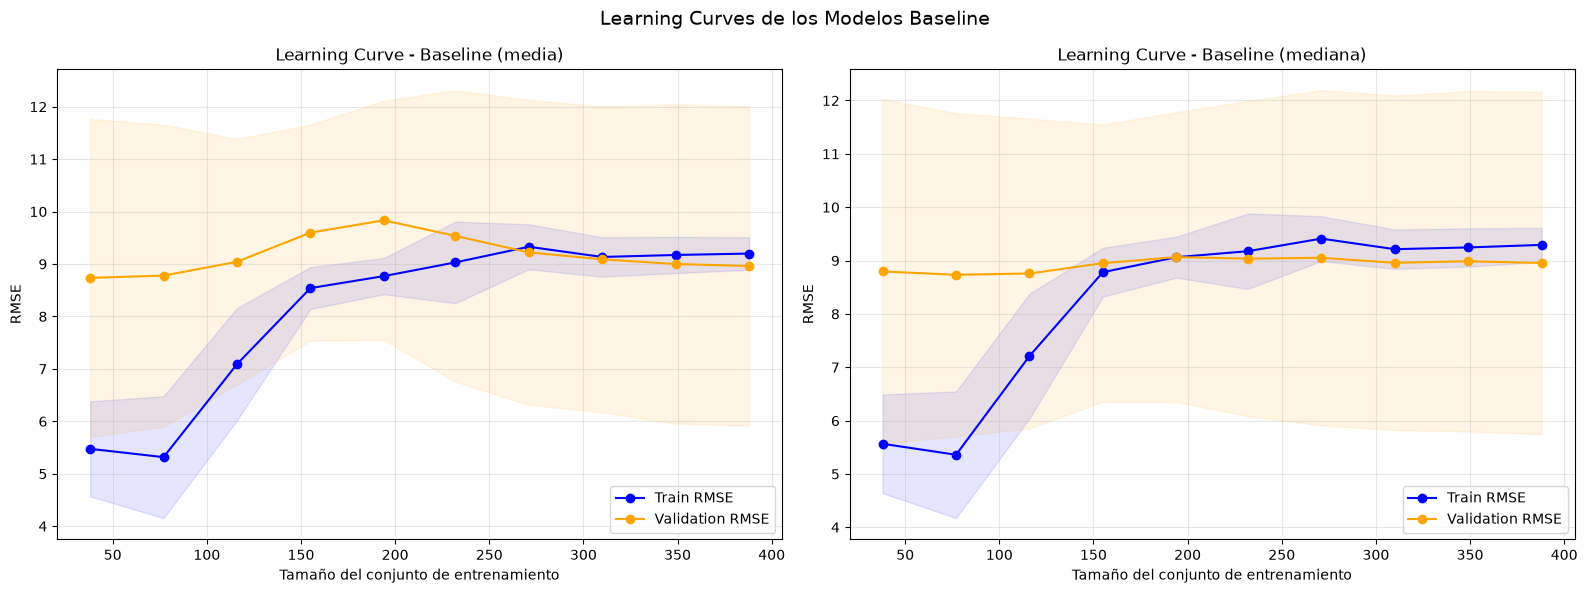

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sizes_mean, train_mean, test_mean = plot_learning_curve(
    baseline_mean, X_cv, y, {"title": "Learning Curve - Baseline (media)", "ax": axes[0]}
)
sizes_median, train_median, test_median = plot_learning_curve(
    baseline_median, X_cv, y, {"title": "Learning Curve - Baseline (mediana)", "ax": axes[1]}
)


plt.suptitle("Learning Curves de los Modelos Baseline", fontsize=14)
plt.tight_layout()
plt.show()

## ⏱️ Gráficas de escalabilidad (tiempo de entrenamiento y score)

In [54]:
def scalability_analysis(estimator, X, y, name):
    """Mide tiempo de entrenamiento y score para diferentes tamaños del dataset."""
    fractions = np.linspace(0.1, 1.0, 10)
    times = []
    scores = []
    sizes = []

    for frac in fractions:
        n = int(len(X) * frac)
        X_sub = X.iloc[:n]
        y_sub = y.iloc[:n]

        start = time.time()
        estimator.fit(X_sub, y_sub)
        elapsed = time.time() - start

        y_pred = estimator.predict(X_sub)
        rmse = np.sqrt(mean_squared_error(y_sub, y_pred))

        times.append(elapsed)
        scores.append(rmse)
        sizes.append(n)

    return sizes, times, scores

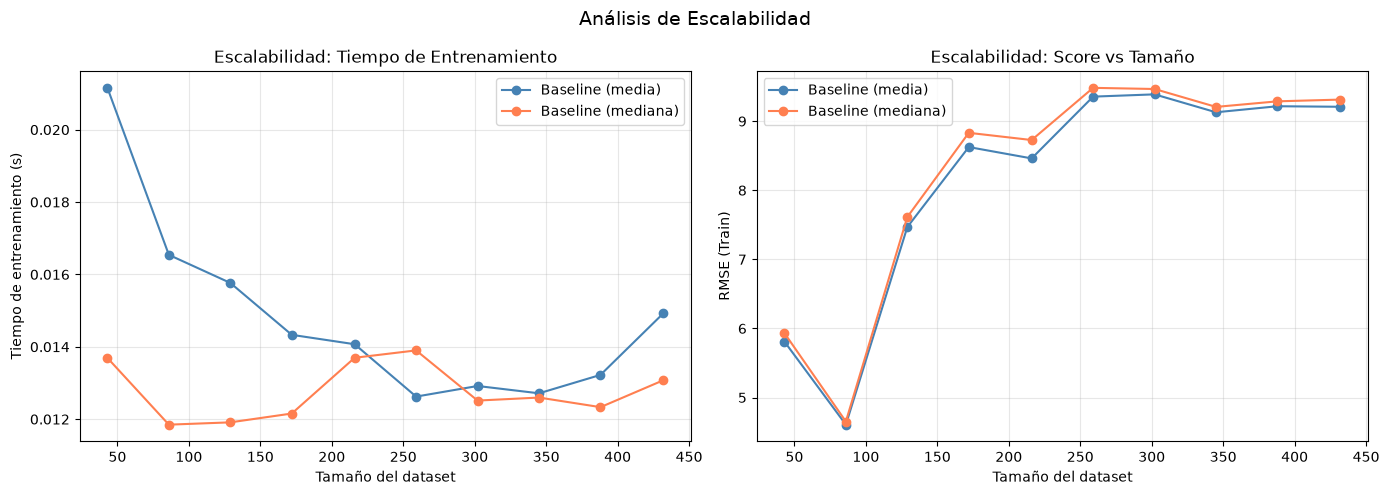

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, model, color in [
    ("Baseline (media)", baseline_mean, "steelblue"),
    ("Baseline (mediana)", baseline_median, "coral"),
]:
    sizes, times, scores = scalability_analysis(model, X_cv, y, name)

    axes[0].plot(sizes, times, "o-", label=name, color=color)
    axes[1].plot(sizes, scores, "o-", label=name, color=color)

axes[0].set_xlabel("Tamaño del dataset")
axes[0].set_ylabel("Tiempo de entrenamiento (s)")
axes[0].set_title("Escalabilidad: Tiempo de Entrenamiento")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Tamaño del dataset")
axes[1].set_ylabel("RMSE (Train)")
axes[1].set_title("Escalabilidad: Score vs Tamaño")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Análisis de Escalabilidad", fontsize=14)
plt.tight_layout()
plt.show()

## 🔍 Análisis de errores

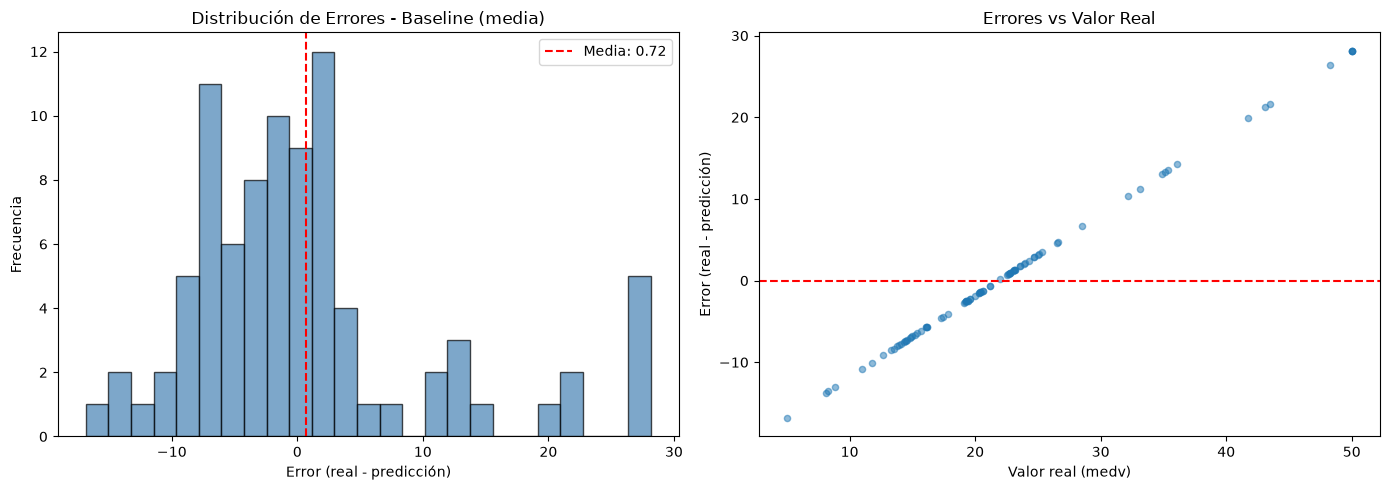

=== Análisis de errores ===
Error medio: 0.7189
Error std:   9.9332
Error min:   -16.8432
Error max:   28.1568


In [56]:
# Distribución de errores del baseline media
baseline_mean.fit(X_train, y_train)
y_pred = baseline_mean.predict(X_test)
errors = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de errores
axes[0].hist(errors, bins=25, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(errors.mean(), color="red", linestyle="--", label=f"Media: {errors.mean():.2f}")
axes[0].set_xlabel("Error (real - predicción)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de Errores - Baseline (media)")
axes[0].legend()

# Errores vs valor real
axes[1].scatter(y_test, errors, alpha=0.5, s=20)
axes[1].axhline(y=0, color="r", linestyle="--")
axes[1].set_xlabel("Valor real (medv)")
axes[1].set_ylabel("Error (real - predicción)")
axes[1].set_title("Errores vs Valor Real")

plt.tight_layout()
plt.show()

print("=== Análisis de errores ===")
print(f"Error medio: {errors.mean():.4f}")
print(f"Error std:   {errors.std():.4f}")
print(f"Error min:   {errors.min():.4f}")
print(f"Error max:   {errors.max():.4f}")

## 💾 Guardar el modelo baseline

In [57]:
# Entrenar con todo el train set y guardar
baseline_mean.fit(X_train, y_train)

model_path = "../../models/baseline_model.joblib"
joblib.dump(baseline_mean, model_path)

# Verificar carga
model_loaded = joblib.load(model_path)
y_verify = model_loaded.predict(X_test)
print(f"Modelo guardado en: {model_path}")
print(f"Verificación: predicciones iguales = {np.allclose(y_pred, y_verify)}")

Modelo guardado en: ../../models/baseline_model.joblib
Verificación: predicciones iguales = True


## 📊 Analysis of Results and Conclusions

### Interpretación de resultados

- **RMSE del baseline (media)**: ~9.22 miles de USD. Esto significa que el modelo se equivoca en promedio ~$9,220 al predecir el precio de una vivienda. Este es el error esperado al no usar ninguna información de los atributos.
- **R² = 0.0**: el modelo no explica ninguna varianza del precio, lo cual es esperado para un DummyRegressor.
- **R² negativo en cross validation**: puede ocurrir cuando el modelo es peor que predecir la media del fold específico.

### Learning Curve

- Las curvas de aprendizaje son planas, lo que confirma que el modelo no aprende de los datos — el RMSE se mantiene constante independientemente del tamaño del dataset.
- No hay gap entre train y validation, lo que indica que no hay ni overfitting ni underfitting — simplemente no hay modelo.

### Análisis de errores

- Los errores se distribuyen simétricamente alrededor de 0 pero con alta dispersión.
- El gráfico de errores vs valor real muestra un patrón claro: subestima viviendas caras y sobreestima viviendas baratas. Esto es exactamente lo esperado cuando se predice siempre la media.

### Conclusiones

- El RMSE de ~9.22 es el **piso de rendimiento** que cualquier modelo de ML debe superar.
- El umbral mínimo aceptable definido en la Tarea 1 es RMSE < 5.0 y R² > 0.70.
- Para superar el baseline se necesita un modelo que capture las relaciones identificadas en el EDA (especialmente con `lstat` y `rm`).

## 💡 Proposals and Ideas

### Recomendaciones para la selección del modelo (Tarea 6)

1. **Modelos lineales regularizados**: Ridge, Lasso y ElasticNet para manejar la multicolinealidad detectada en el EDA.
2. **Modelos basados en árboles**: Random Forest y Gradient Boosting (XGBoost, LightGBM) para capturar relaciones no lineales sin necesidad de transformaciones adicionales.
3. **SVR (Support Vector Regression)**: para explorar un enfoque diferente con kernel RBF.
4. **KNN Regressor**: modelo basado en instancias que podría capturar patrones locales.

### Métricas objetivo

| Métrica | Baseline | Objetivo mínimo | Objetivo ideal |
|---------|----------|----------------|----------------|
| RMSE | ~9.22 | < 5.00 | < 3.50 |
| R² | 0.00 | > 0.70 | > 0.85 |

### Estrategia de optimización

- Usar cross validation con el pipeline completo (preprocessor + modelo) para evitar data leakage.
- Optimizar hiperparámetros con GridSearchCV o RandomizedSearchCV para los 2-3 mejores modelos.
- Comparar resultados con pruebas estadísticas para seleccionar el mejor modelo.

## 📖 References

- Guía del proyecto (Tarea 5): [joserzapata.github.io/post/ciencia-datos-proyecto-python/5-baseline_model/](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/5-baseline_model/)
- Scikit-learn DummyRegressor: [sklearn.dummy.DummyRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html)
- Scikit-learn Learning Curve: [sklearn.model_selection.learning_curve](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html)
- Scikit-learn Cross Validation: [sklearn.model_selection.cross_validate](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html)